# SIMULACIONES

Creo un video con una animación de la matriz de matriz.txt para ver las partículas.

In [ ]:
### PARA VIDEO ##########################

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import cv2

# =========================================================
# PARÁMETROS
# =========================================================
nombre_archivo = "MATRIZ.txt"
nombre_video = "evolucion_matriz.mp4"
fps = 10

# =========================================================
# FUNCIÓN PARA LEER LAS MATRICES DEL ARCHIVO
# =========================================================
def leer_matrices(nombre_archivo):
    with open(nombre_archivo, "r") as f:
        lineas = f.readlines()

    matrices = []
    bloque = []

    for linea in lineas:
        linea = linea.strip()

        if linea == "":
            if bloque:
                matriz = []
                for fila in bloque:
                    valores = [int(x) for x in fila.split()]
                    matriz.append(valores)
                matrices.append(np.array(matriz))
                bloque = []
        else:
            bloque.append(linea)

    # Por si el archivo no termina con línea vacía
    if bloque:
        matriz = []
        for fila in bloque:
            valores = [int(x) for x in fila.split()]
            matriz.append(valores)
        matrices.append(np.array(matriz))

    return matrices

# =========================================================
# LEER MATRICES
# =========================================================
matrices = leer_matrices(nombre_archivo)

if len(matrices) == 0:
    raise ValueError("No se ha encontrado ninguna matriz en el archivo.")

n_filas, n_columnas = matrices[0].shape

# =========================================================
# MAPA DE COLORES
# 0 -> blanco
# 1 -> azul
# 2 -> rojo
# =========================================================
cmap = ListedColormap(["white", "blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# =========================================================
# CREAR FIGURA
# =========================================================
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ancho = int(fig.get_figwidth() * fig.dpi)
alto = int(fig.get_figheight() * fig.dpi)

# =========================================================
# CREAR EL ESCRITOR DE VÍDEO
# =========================================================
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(nombre_video, fourcc, fps, (ancho, alto))

if not video.isOpened():
    raise ValueError("No se pudo abrir el escritor de vídeo. Prueba a instalar opencv correctamente o usar otro codec.")

# =========================================================
# GENERAR LOS FRAMES
# =========================================================
for contador, matriz in enumerate(matrices):
    ax.clear()

    ax.imshow(matriz, cmap=cmap, norm=norm)

    # Cuadrícula
    ax.set_xticks(np.arange(-0.5, n_columnas, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_filas, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=1)

    # Quitamos numeritos de los ejes
    ax.set_xticks([])
    ax.set_yticks([])

    # Título con el paso
    ax.set_title(f"Paso = {contador}", fontsize=16)

    plt.tight_layout()

    # Convertir la figura de matplotlib a imagen
    fig.canvas.draw()
    imagen = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    imagen = imagen.reshape(alto, ancho, 4)

    # Pasar de RGBA a BGR para OpenCV
    frame_bgr = cv2.cvtColor(imagen, cv2.COLOR_RGBA2BGR)

    # Escribir frame en el vídeo
    video.write(frame_bgr)

# =========================================================
# CERRAR TODO
# =========================================================
video.release()
plt.close(fig)

print(f"Vídeo guardado como: {nombre_video}")

Vídeo guardado como: evolucion_matriz.mp4


## Código para plotear la densidad y la presión

### Densidad sin promediar

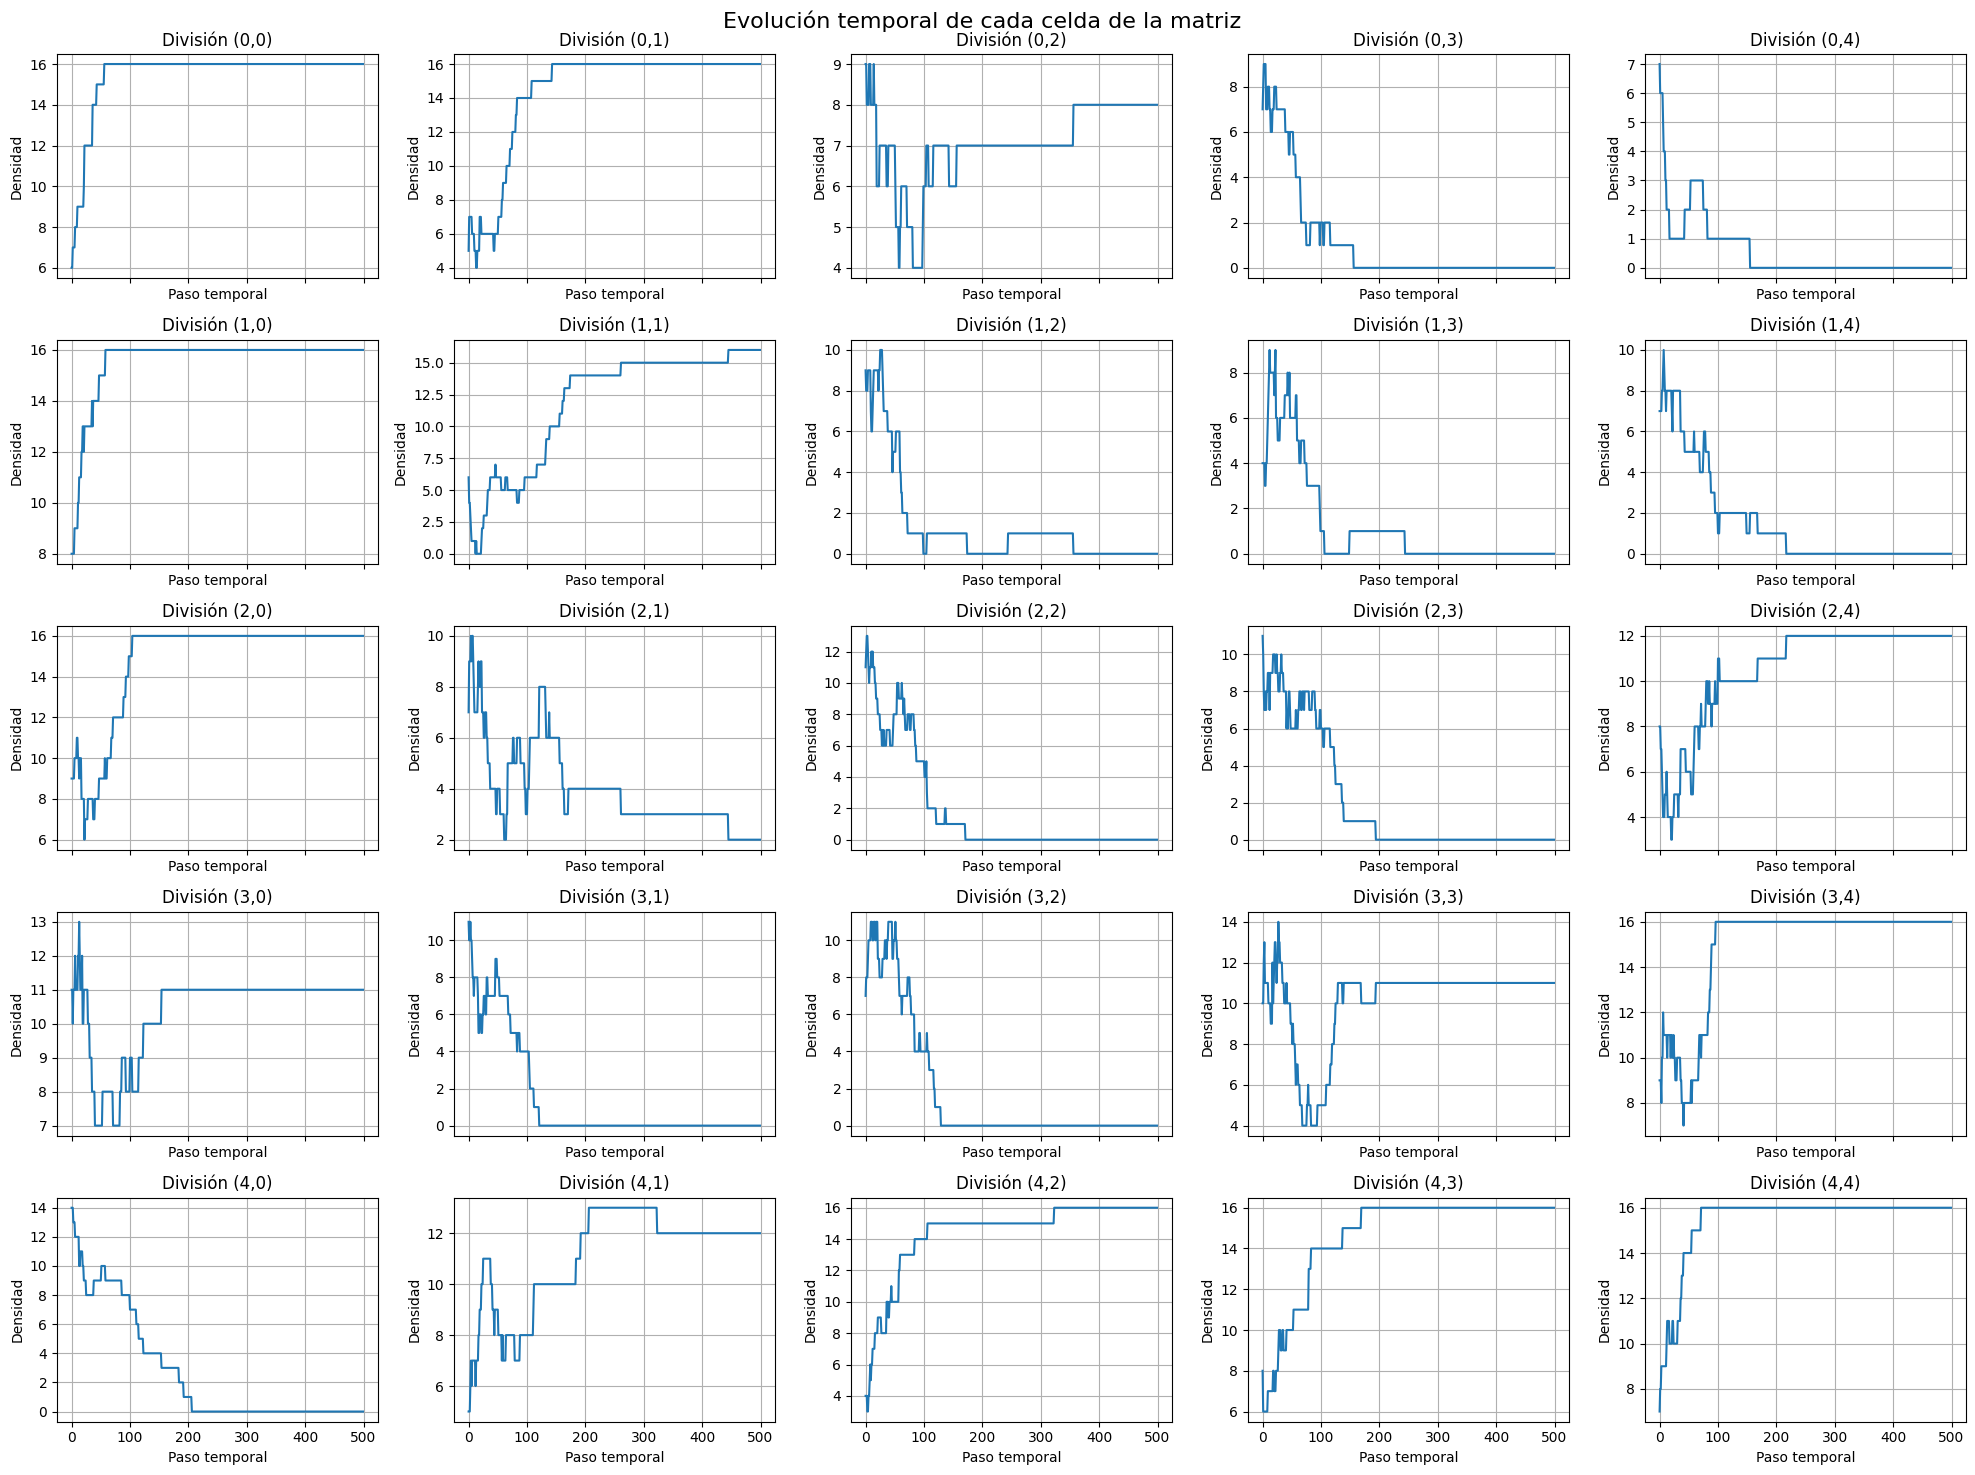

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("densidad.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()


# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")


matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"División ({i},{j})")
        axes[i, j].set_xlabel("Paso temporal")
        axes[i, j].set_ylabel("Densidad")
        axes[i, j].grid(True)

fig.suptitle("Evolución temporal de cada celda de la matriz", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("plots/evolucion_densidad_celdas.png", dpi=300, bbox_inches="tight")

# Mostrar
plt.show()

### Presión sin promediar

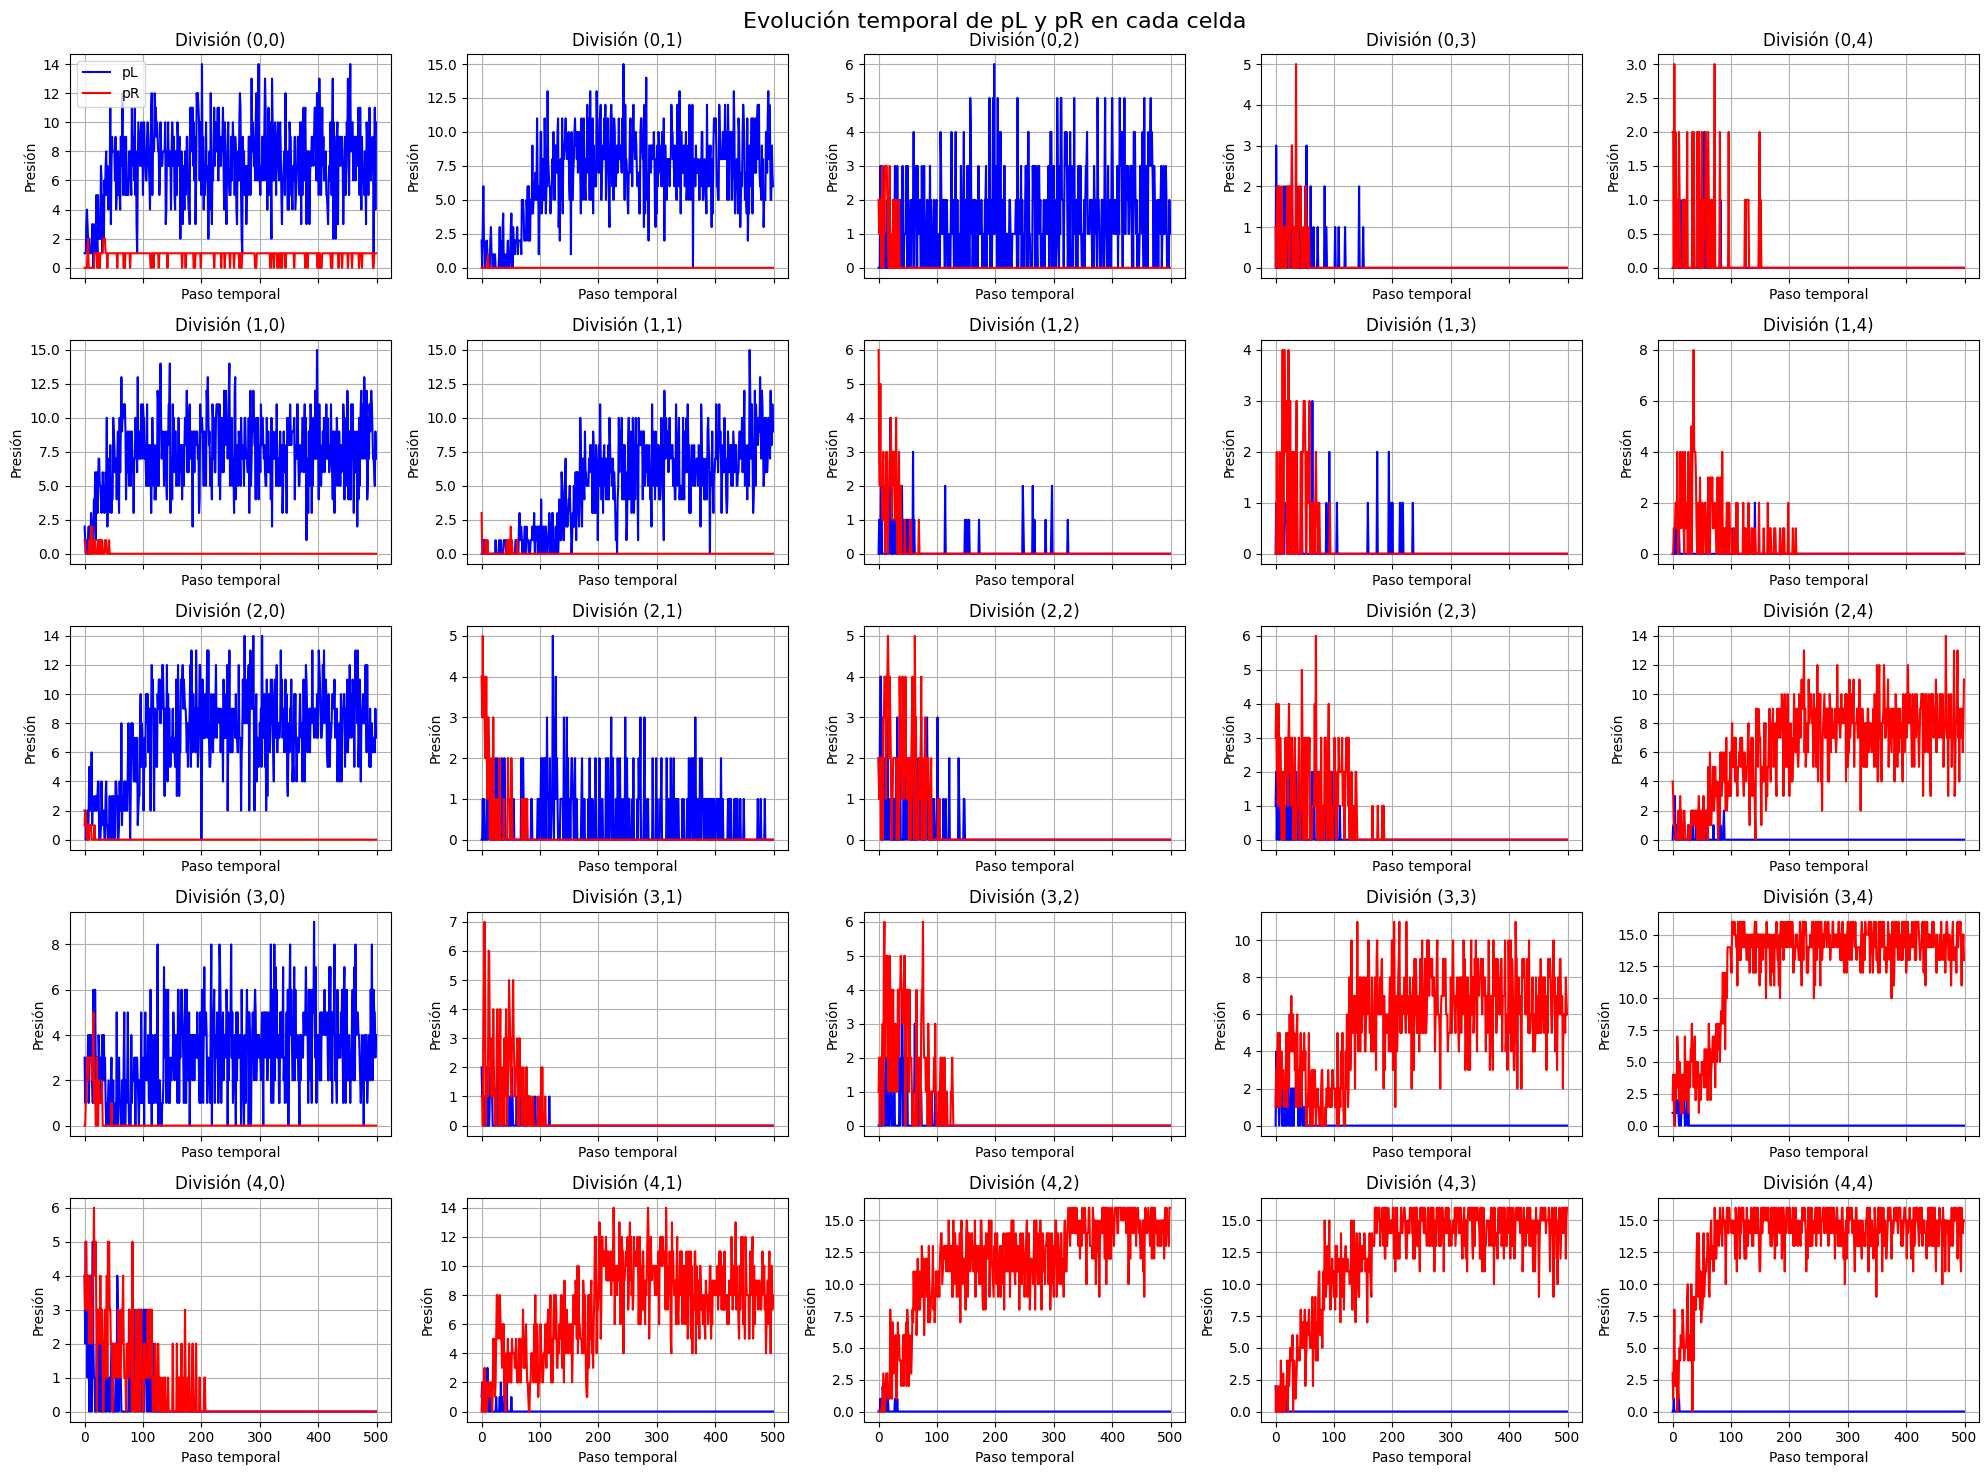

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ===== FUNCIÓN PARA LEER UN FICHERO DE MATRICES =====
def leer_fichero_presion(nombre_fichero):
    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    # Cada bloque separado por una línea en blanco es una matriz
    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


# ===== LEER LOS DOS FICHEROS =====
datos_L = leer_fichero_presion("presionL.txt")
datos_R = leer_fichero_presion("presionR.txt")


# ===== COMPROBAR QUE TIENEN LA MISMA FORMA =====
if datos_L.shape != datos_R.shape:
    print("ERROR: presionL.txt y presionR.txt no tienen las mismas dimensiones")
    print("Forma de datos_L:", datos_L.shape)
    print("Forma de datos_R:", datos_R.shape)
else:

    # dimensiones: (tiempo, filas, columnas)
    num_tiempos = datos_L.shape[0]
    num_filas = datos_L.shape[1]
    num_columnas = datos_L.shape[2]

    # Vector temporal
    t = np.arange(num_tiempos)

    # ===== HACER LA FIGURA =====
    fig, axes = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(4*num_columnas, 3*num_filas),
        sharex=True
    )

    # Por si alguna vez la matriz fuese de 1 fila o 1 columna
    if num_filas == 1 and num_columnas == 1:
        axes = np.array([[axes]])
    elif num_filas == 1:
        axes = axes[np.newaxis, :]
    elif num_columnas == 1:
        axes = axes[:, np.newaxis]

    # ===== PLOT DE CADA CELDA =====
    for i in range(num_filas):
        for j in range(num_columnas):

            axes[i, j].plot(t, datos_L[:, i, j], color="blue", label="pL")
            axes[i, j].plot(t, datos_R[:, i, j], color="red", label="pR")

            axes[i, j].set_title(f"División ({i},{j})")
            axes[i, j].set_xlabel("Paso temporal")
            axes[i, j].set_ylabel("Presión")
            axes[i, j].grid(True)

            # Para no saturar mucho, puedes poner leyenda solo en una celda
            if i == 0 and j == 0:
                axes[i, j].legend()

    fig.suptitle("Evolución temporal de pL y pR en cada celda", fontsize=16)
    fig.tight_layout()

    # Guardar imagen
    plt.savefig("plots/evolucion_presion_L_R_celdas.png", dpi=300, bbox_inches="tight")

    # Mostrar
    plt.show()

### Densidad promediada

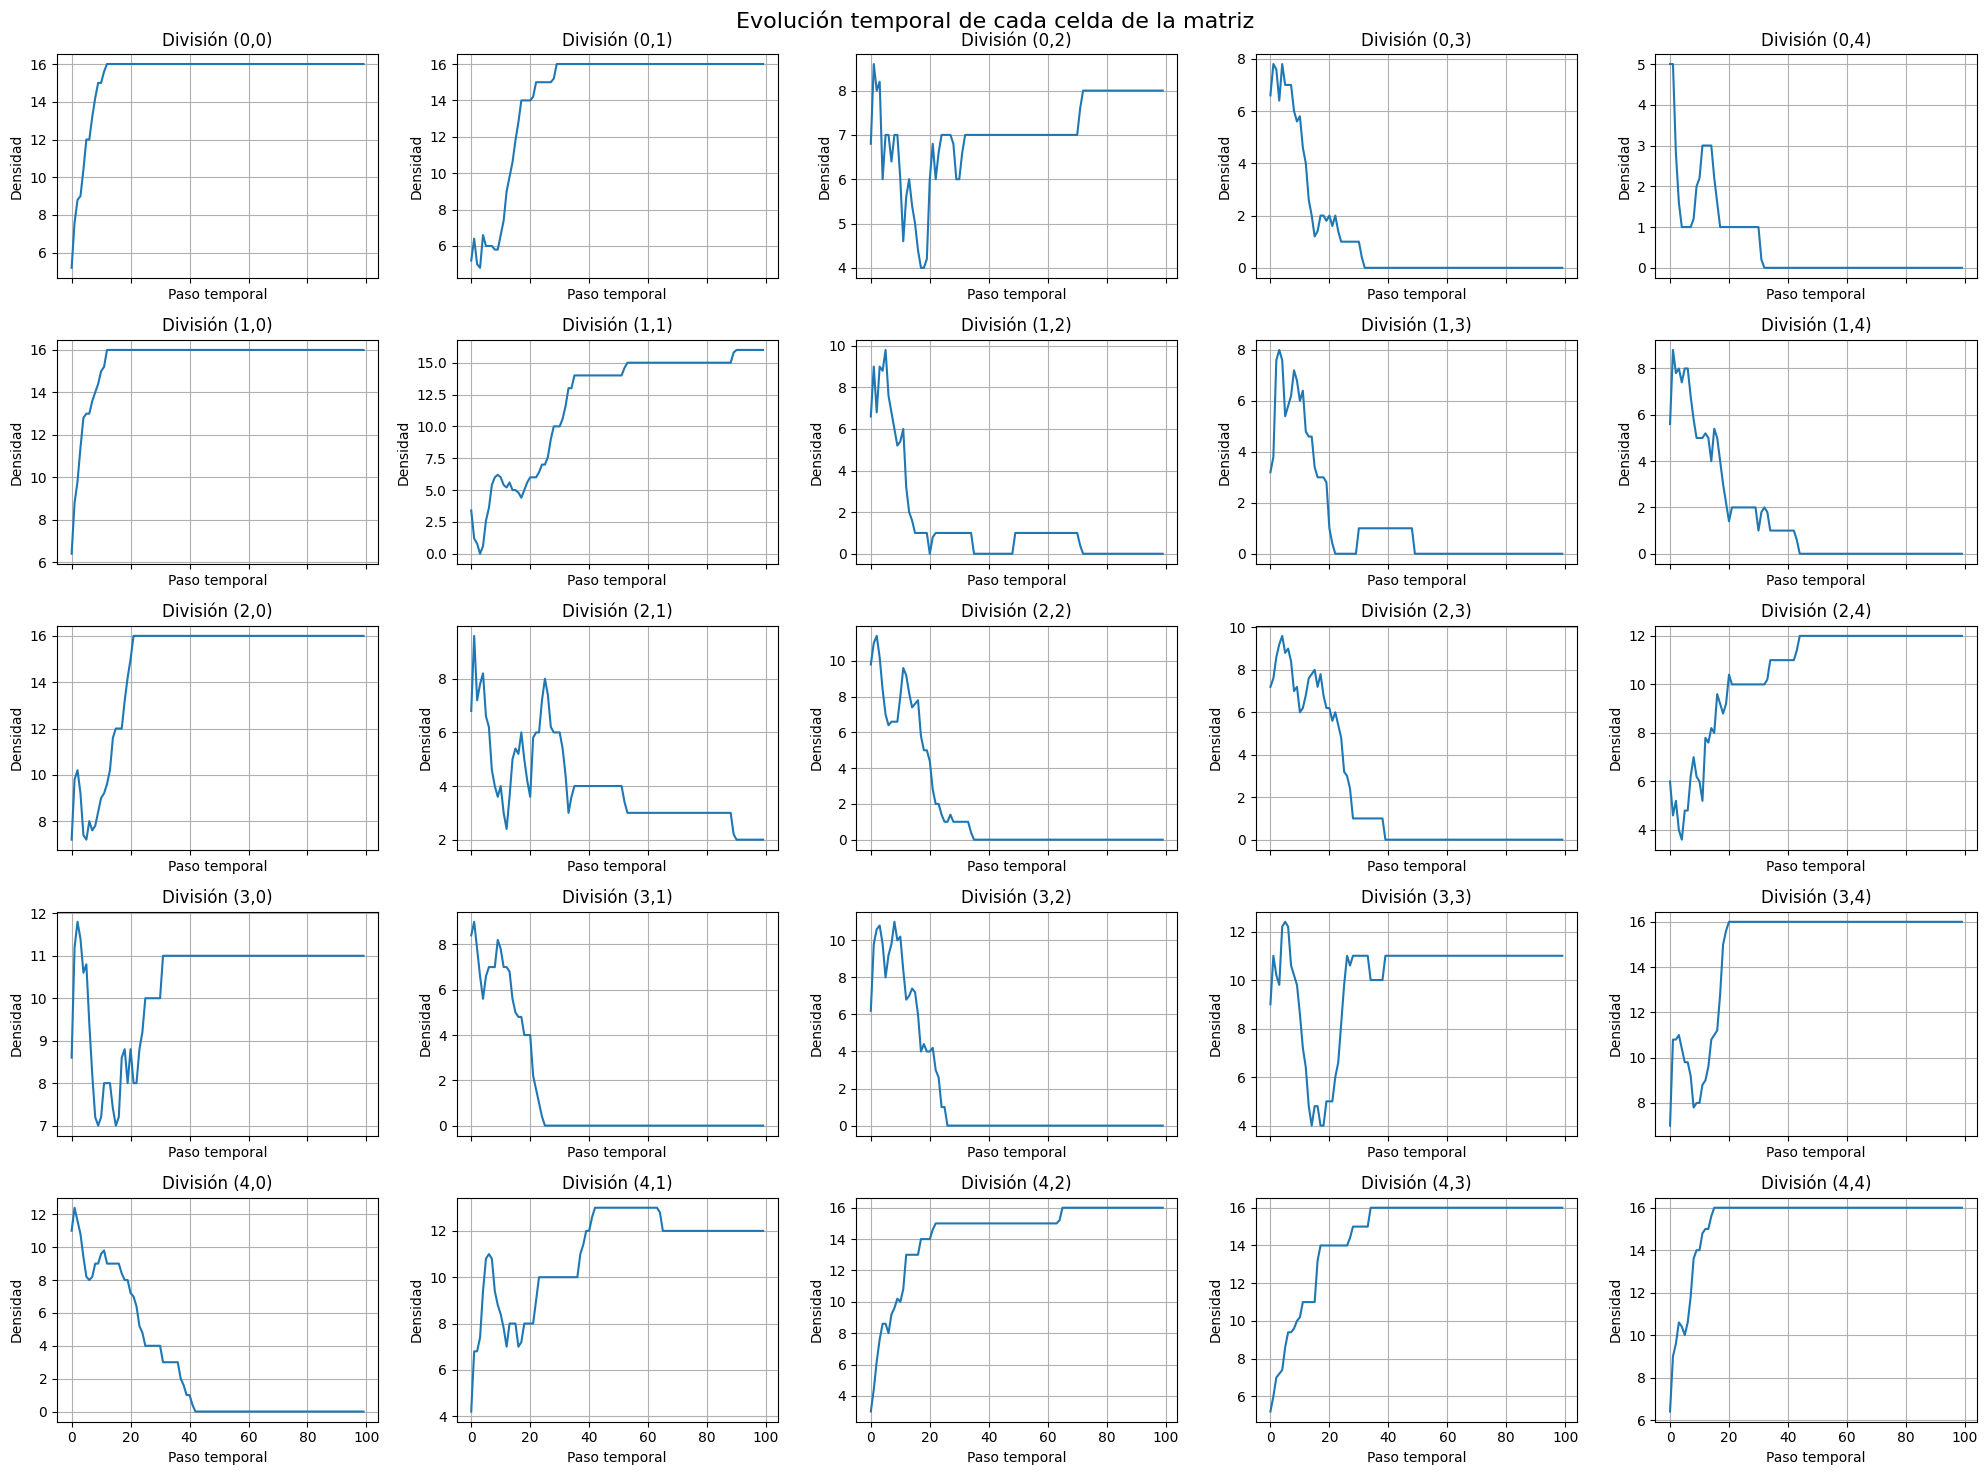

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ===== LEER EL FICHERO =====
with open("densidad2.txt", "r", encoding="utf-8") as f:
    texto = f.read().strip()


# ===== SEPARAR LOS PASOS TEMPORALES =====
# Cada bloque separado por una línea en blanco es una matriz en un instante de tiempo
bloques = texto.split("\n\n")


matrices = []

for bloque in bloques:
    lineas = bloque.strip().split("\n")
    matriz = []

    for linea in lineas:
        fila = list(map(float, linea.split()))
        matriz.append(fila)

    matrices.append(matriz)

# Convertimos a array de numpy
datos = np.array(matrices)

# dimensiones: (tiempo, filas, columnas)
num_tiempos = datos.shape[0]
num_filas = datos.shape[1]
num_columnas = datos.shape[2]

# Vector temporal
t = np.arange(num_tiempos)

# ===== HACER LA FIGURA =====
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(4*num_columnas, 3*num_filas), sharex=True)

# Por si alguna vez la matriz fuese de 1 fila o 1 columna
if num_filas == 1 and num_columnas == 1:
    axes = np.array([[axes]])
elif num_filas == 1:
    axes = axes[np.newaxis, :]
elif num_columnas == 1:
    axes = axes[:, np.newaxis]

# ===== PLOT DE CADA CELDA =====
for i in range(num_filas):
    for j in range(num_columnas):
        axes[i, j].plot(t, datos[:, i, j])
        axes[i, j].set_title(f"División ({i},{j})")
        axes[i, j].set_xlabel("Paso temporal")
        axes[i, j].set_ylabel("Densidad")
        axes[i, j].grid(True)

fig.suptitle("Evolución temporal de cada celda de la matriz", fontsize=16)
fig.tight_layout()

# Guardar imagen
plt.savefig("plots/evolucion_densidad_celdas_PROMEDIO.png", dpi=300, bbox_inches="tight")

# Mostrar
plt.show()

### Presión promediada

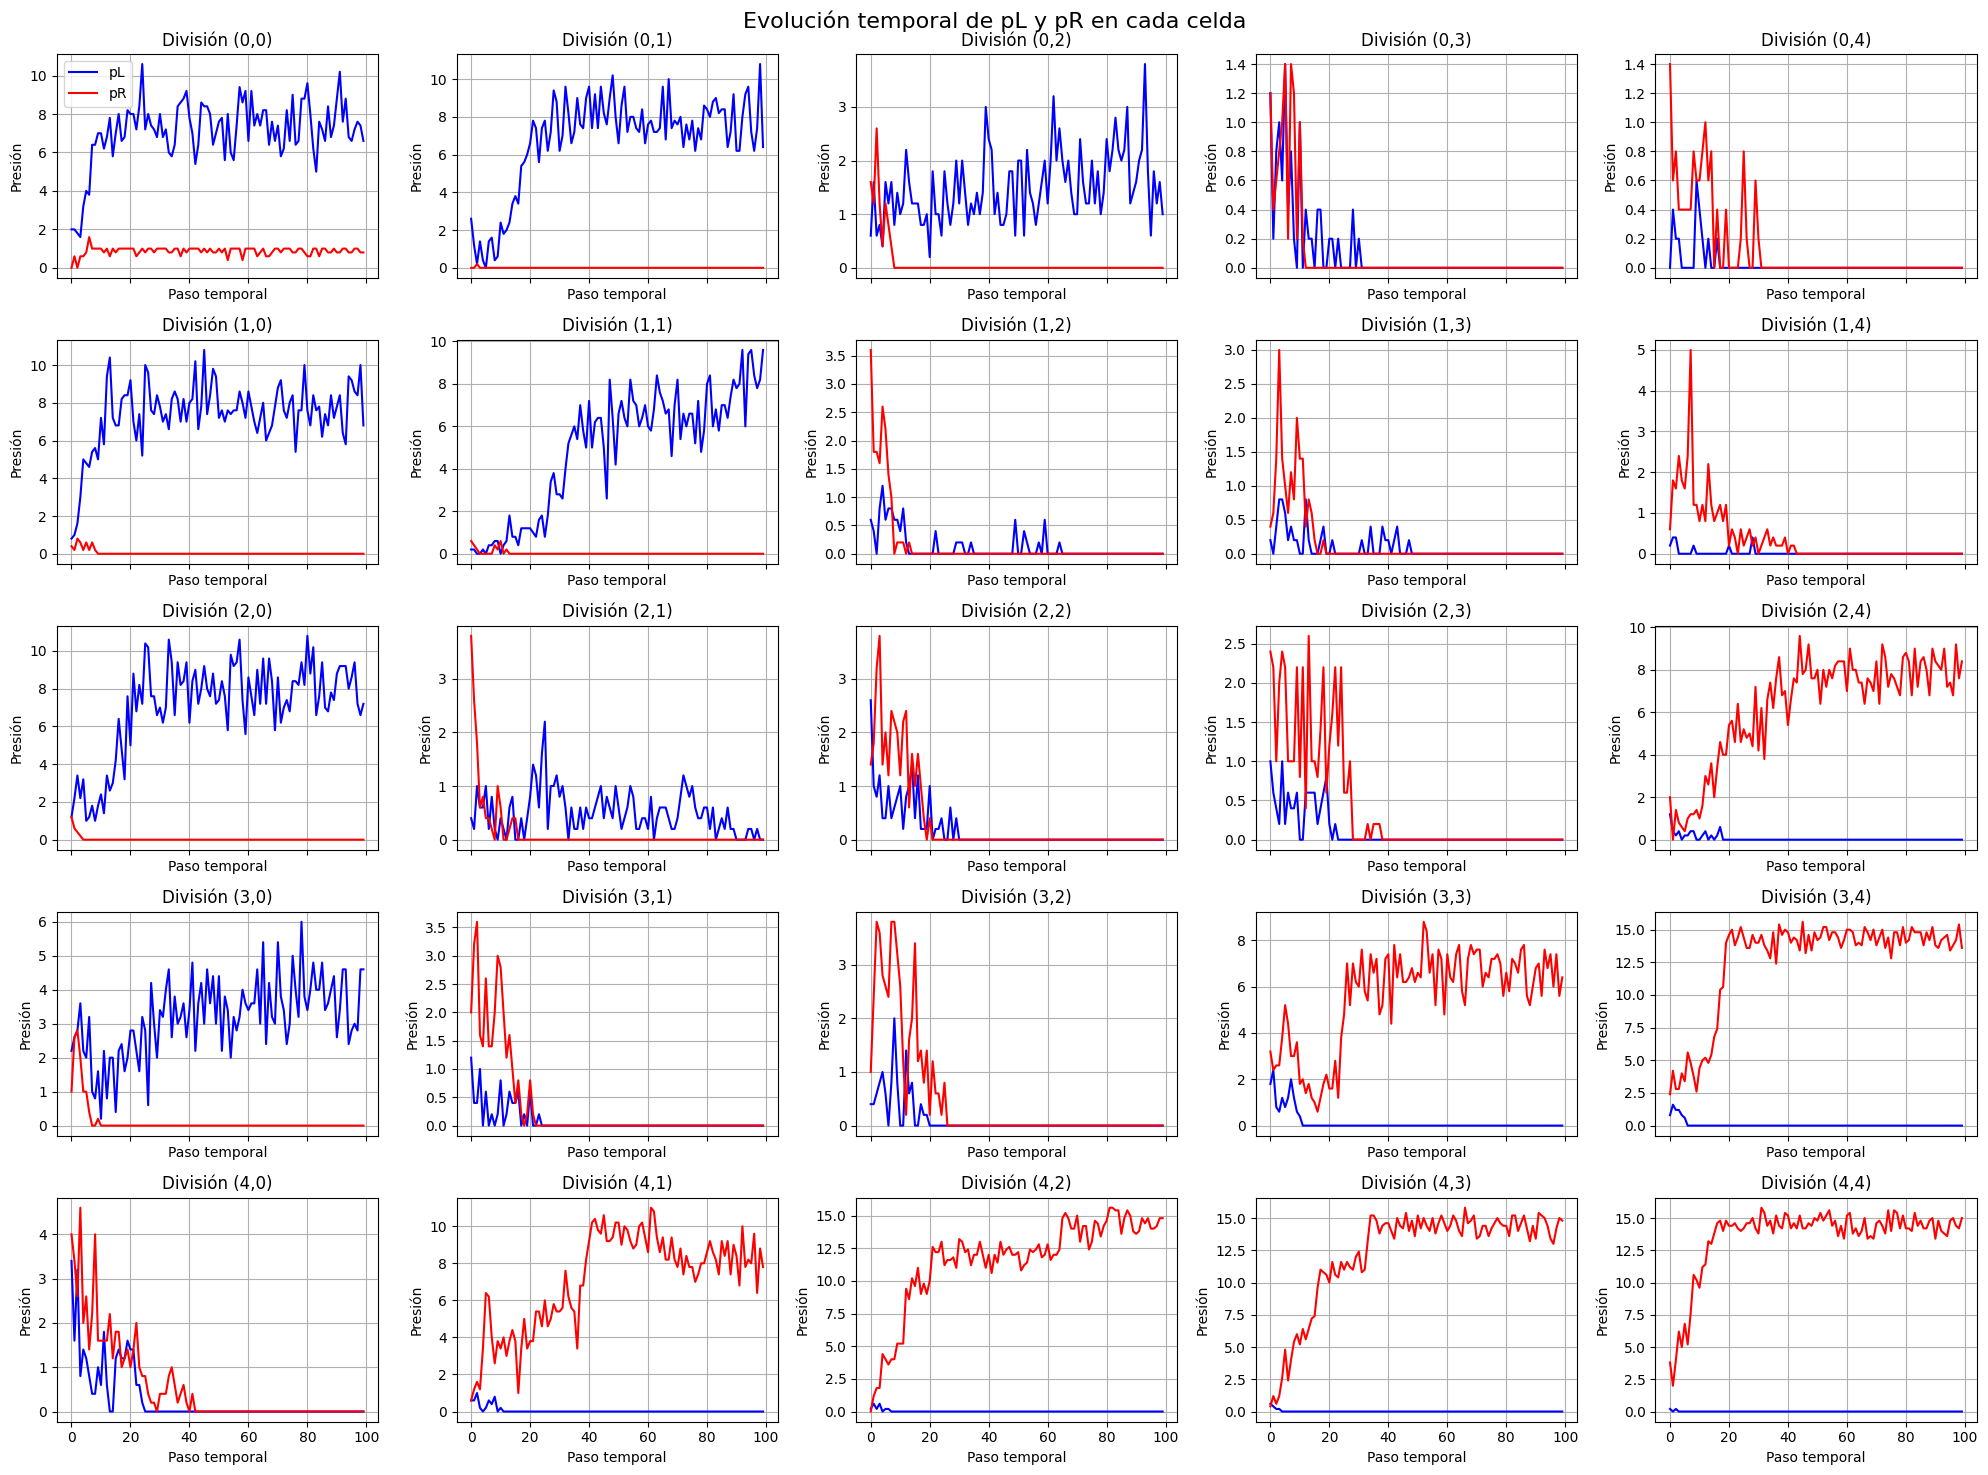

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# ===== FUNCIÓN PARA LEER UN FICHERO DE MATRICES =====
def leer_fichero_presion(nombre_fichero):
    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    # Cada bloque separado por una línea en blanco es una matriz
    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


# ===== LEER LOS DOS FICHEROS =====
datos_L = leer_fichero_presion("presionL2.txt")
datos_R = leer_fichero_presion("presionR2.txt")


# ===== COMPROBAR QUE TIENEN LA MISMA FORMA =====
if datos_L.shape != datos_R.shape:
    print("ERROR: presionL2.txt y presionR2.txt no tienen las mismas dimensiones")
    print("Forma de datos_L:", datos_L.shape)
    print("Forma de datos_R:", datos_R.shape)
else:

    # dimensiones: (tiempo, filas, columnas)
    num_tiempos = datos_L.shape[0]
    num_filas = datos_L.shape[1]
    num_columnas = datos_L.shape[2]

    # Vector temporal
    t = np.arange(num_tiempos)

    # ===== HACER LA FIGURA =====
    fig, axes = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(4*num_columnas, 3*num_filas),
        sharex=True
    )

    # Por si alguna vez la matriz fuese de 1 fila o 1 columna
    if num_filas == 1 and num_columnas == 1:
        axes = np.array([[axes]])
    elif num_filas == 1:
        axes = axes[np.newaxis, :]
    elif num_columnas == 1:
        axes = axes[:, np.newaxis]

    # ===== PLOT DE CADA CELDA =====
    for i in range(num_filas):
        for j in range(num_columnas):

            axes[i, j].plot(t, datos_L[:, i, j], color="blue", label="pL")
            axes[i, j].plot(t, datos_R[:, i, j], color="red", label="pR")

            axes[i, j].set_title(f"División ({i},{j})")
            axes[i, j].set_xlabel("Paso temporal")
            axes[i, j].set_ylabel("Presión")
            axes[i, j].grid(True)

            # Para no saturar mucho, puedes poner leyenda solo en una celda
            if i == 0 and j == 0:
                axes[i, j].legend()

    fig.suptitle("Evolución temporal de pL y pR en cada celda", fontsize=16)
    fig.tight_layout()

    # Guardar imagen
    plt.savefig("plots/evolucion_presion_L_R_celdas_PROMEDIO.png", dpi=300, bbox_inches="tight")

    # Mostrar
    plt.show()

### Código para promediar la DENSIDAD y PRESIÓN

Dimensiones densidad: (500, 5, 5)
Dimensiones presionL: (500, 5, 5)
Dimensiones presionR: (500, 5, 5)


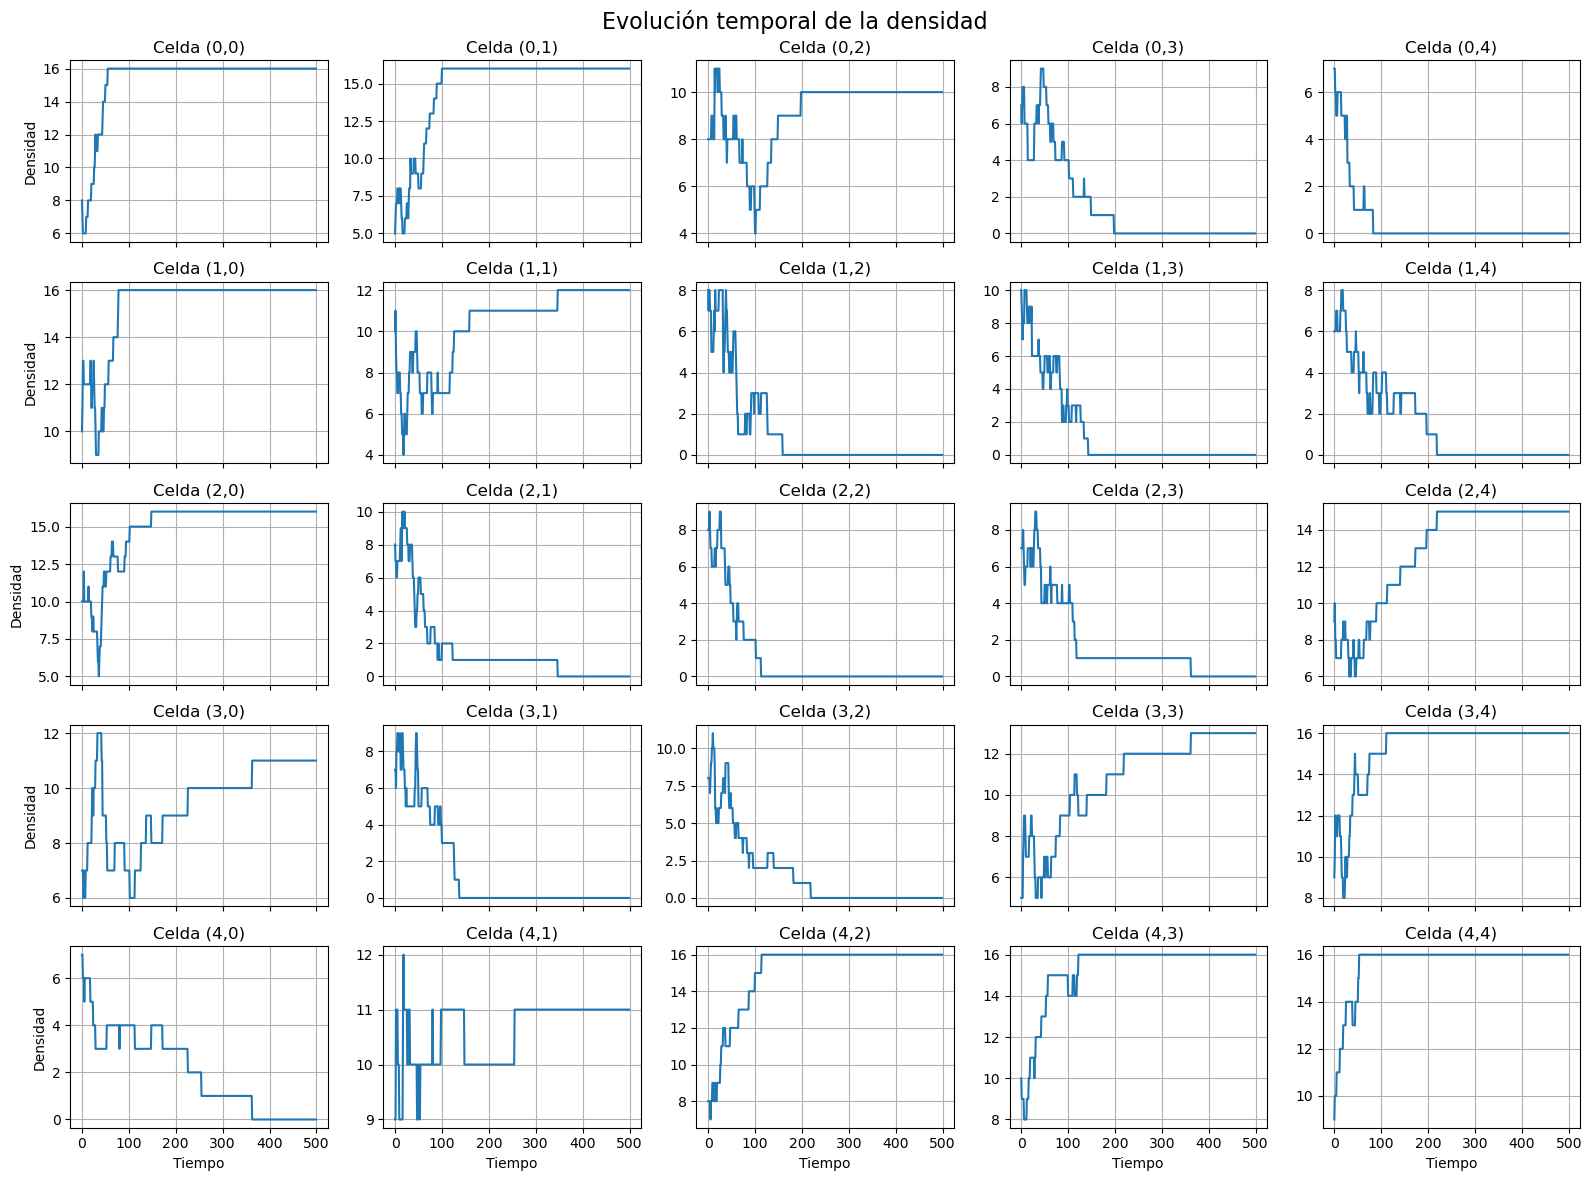

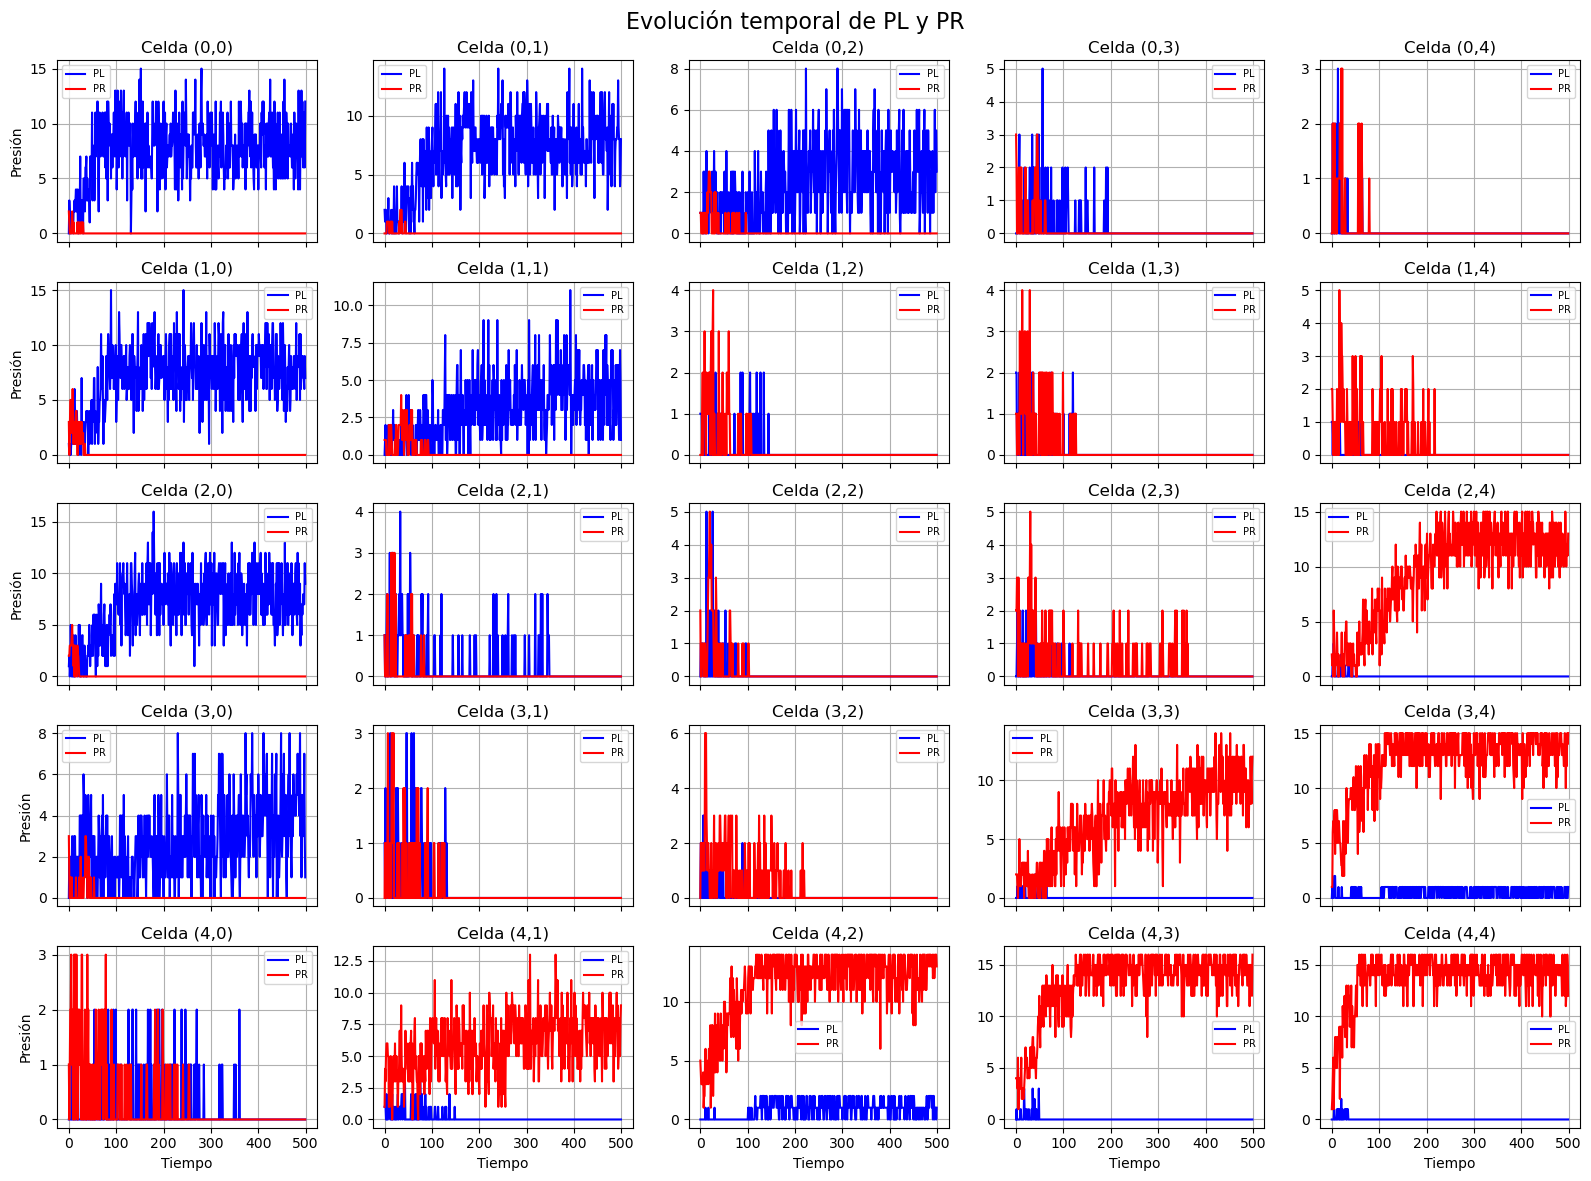

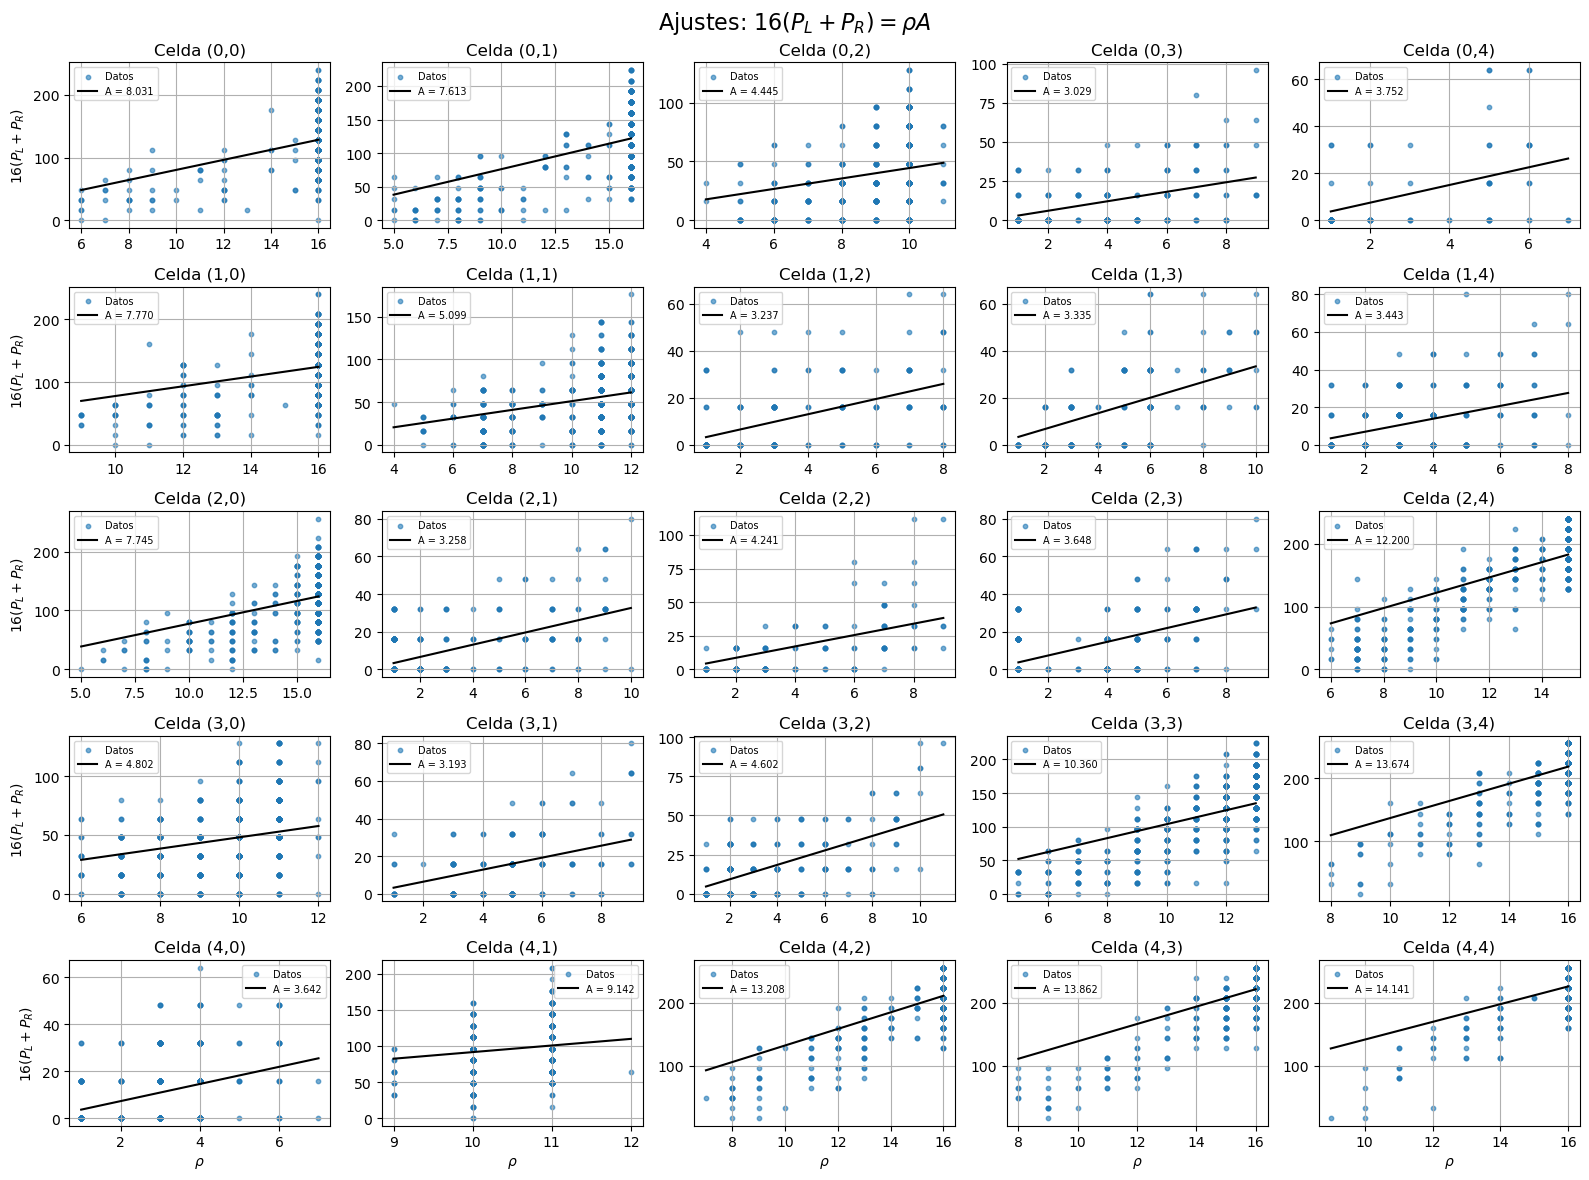


Matriz de valores de A:
[[ 8.0305135   7.61275373  4.44471406  3.02884111  3.75206612]
 [ 7.76967551  5.09898403  3.23715693  3.3352999   3.44323284]
 [ 7.74523284  3.25801953  4.24103512  3.64775797 12.19953538]
 [ 4.80235733  3.19331243  4.60153257 10.36014928 13.67406119]
 [ 3.64160184  9.14212648 13.20762245 13.86249407 14.14130523]]

Matriz de valores de A redondeada:
[[ 8.031  7.613  4.445  3.029  3.752]
 [ 7.77   5.099  3.237  3.335  3.443]
 [ 7.745  3.258  4.241  3.648 12.2  ]
 [ 4.802  3.193  4.602 10.36  13.674]
 [ 3.642  9.142 13.208 13.862 14.141]]


In [4]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FUNCIONES
# ============================================================

def leer_matrices_txt(nombre_fichero):
    """
    Lee un fichero donde:
    - cada línea es una fila de una matriz
    - los números están separados por espacios o tabuladores
    - una línea vacía separa pasos temporales

    Devuelve un array con dimensiones:
    datos[tiempo, fila, columna]
    """

    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:
        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            fila = list(map(float, linea.split()))
            matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


def plot_evolucion_densidad(densidad):
    """
    Plotea la evolución temporal de la densidad en cada celda del grid.
    """

    num_tiempos = densidad.shape[0]
    num_filas = densidad.shape[1]
    num_columnas = densidad.shape[2]

    tiempos = np.arange(num_tiempos)

    fig, axs = plt.subplots(num_filas, num_columnas, figsize=(16, 12), sharex=True)

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            y = densidad[:, i, j]

            ax.plot(tiempos, y)
            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel("Tiempo")

            if j == 0:
                ax.set_ylabel("Densidad")

    fig.suptitle("Evolución temporal de la densidad", fontsize=16)
    plt.tight_layout()
    plt.savefig("evolucion_densidad.png", dpi=300)
    plt.show()


def plot_evolucion_presiones(presionL, presionR):
    """
    Plotea PL y PR juntas en cada celda del grid.
    PL en azul.
    PR en rojo.
    """

    num_tiempos = presionL.shape[0]
    num_filas = presionL.shape[1]
    num_columnas = presionL.shape[2]

    tiempos = np.arange(num_tiempos)

    fig, axs = plt.subplots(num_filas, num_columnas, figsize=(16, 12), sharex=True)

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            yL = presionL[:, i, j]
            yR = presionR[:, i, j]

            ax.plot(tiempos, yL, color="blue", label="PL")
            ax.plot(tiempos, yR, color="red", label="PR")

            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel("Tiempo")

            if j == 0:
                ax.set_ylabel("Presión")

            ax.legend(fontsize=7)

    fig.suptitle("Evolución temporal de PL y PR", fontsize=16)
    plt.tight_layout()
    plt.savefig("evolucion_presiones_PL_PR.png", dpi=300)
    plt.show()


def calcular_A_y_plot_ajustes(densidad, presionL, presionR):
    """
    Para cada celda del grid ajusta:

        16 * (PL + PR) = densidad * A

    Es decir:

        y = A x

    donde:
        x = densidad
        y = 16 * (PL + PR)

    El ajuste se hace pasando por el origen, porque la fórmula física
    no tiene término independiente.
    """

    num_tiempos = densidad.shape[0]
    num_filas = densidad.shape[1]
    num_columnas = densidad.shape[2]

    matriz_A = np.zeros((num_filas, num_columnas))

    fig, axs = plt.subplots(num_filas, num_columnas, figsize=(16, 12))

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            x = densidad[:, i, j]
            y = 16 * (presionL[:, i, j] + presionR[:, i, j])

            # Quitamos los puntos con densidad cero porque no aportan al ajuste y = A*x
            x_ajuste = []
            y_ajuste = []

            for k in range(num_tiempos):
                if x[k] != 0:
                    x_ajuste.append(x[k])
                    y_ajuste.append(y[k])

            x_ajuste = np.array(x_ajuste)
            y_ajuste = np.array(y_ajuste)

            # Ajuste y = A*x pasando por el origen:
            # A = sum(x*y) / sum(x^2)
            if np.sum(x_ajuste**2) != 0:
                A = np.sum(x_ajuste * y_ajuste) / np.sum(x_ajuste**2)
            else:
                A = np.nan

            matriz_A[i, j] = A

            # Puntos experimentales
            ax.scatter(x_ajuste, y_ajuste, s=10, alpha=0.6, label="Datos")

            # Recta ajustada
            x_recta = np.linspace(np.min(x_ajuste), np.max(x_ajuste), 100)
            y_recta = A * x_recta

            ax.plot(x_recta, y_recta, color="black", label=f"A = {A:.3f}")

            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel(r"$\rho$")

            if j == 0:
                ax.set_ylabel(r"$16(P_L + P_R)$")

            ax.legend(fontsize=7)

    fig.suptitle(r"Ajustes: $16(P_L + P_R) = \rho A$", fontsize=16)
    plt.tight_layout()
    plt.savefig("ajustes_temperatura_A.png", dpi=300)
    plt.show()

    return matriz_A


# ============================================================
# PROGRAMA PRINCIPAL
# ============================================================

densidad = leer_matrices_txt("densidad.txt")
presionL = leer_matrices_txt("presionL.txt")
presionR = leer_matrices_txt("presionR.txt")

print("Dimensiones densidad:", densidad.shape)
print("Dimensiones presionL:", presionL.shape)
print("Dimensiones presionR:", presionR.shape)

# Comprobación de seguridad
if densidad.shape != presionL.shape or densidad.shape != presionR.shape:
    raise ValueError("Los tres ficheros no tienen las mismas dimensiones.")

# 1) Plot densidad
plot_evolucion_densidad(densidad)

# 2) Plot PL y PR juntos
plot_evolucion_presiones(presionL, presionR)

# 3) Cálculo de A y plots de ajuste
matriz_A = calcular_A_y_plot_ajustes(densidad, presionL, presionR)

print("\nMatriz de valores de A:")
print(matriz_A)

print("\nMatriz de valores de A redondeada:")
print(np.round(matriz_A, 3))


Dimensiones originales:
densidad: (500, 5, 5)
presionL: (500, 5, 5)
presionR: (500, 5, 5)

Dimensiones promediadas:
densidad_promedio: (100, 5, 5)
presionL_promedio: (100, 5, 5)
presionR_promedio: (100, 5, 5)


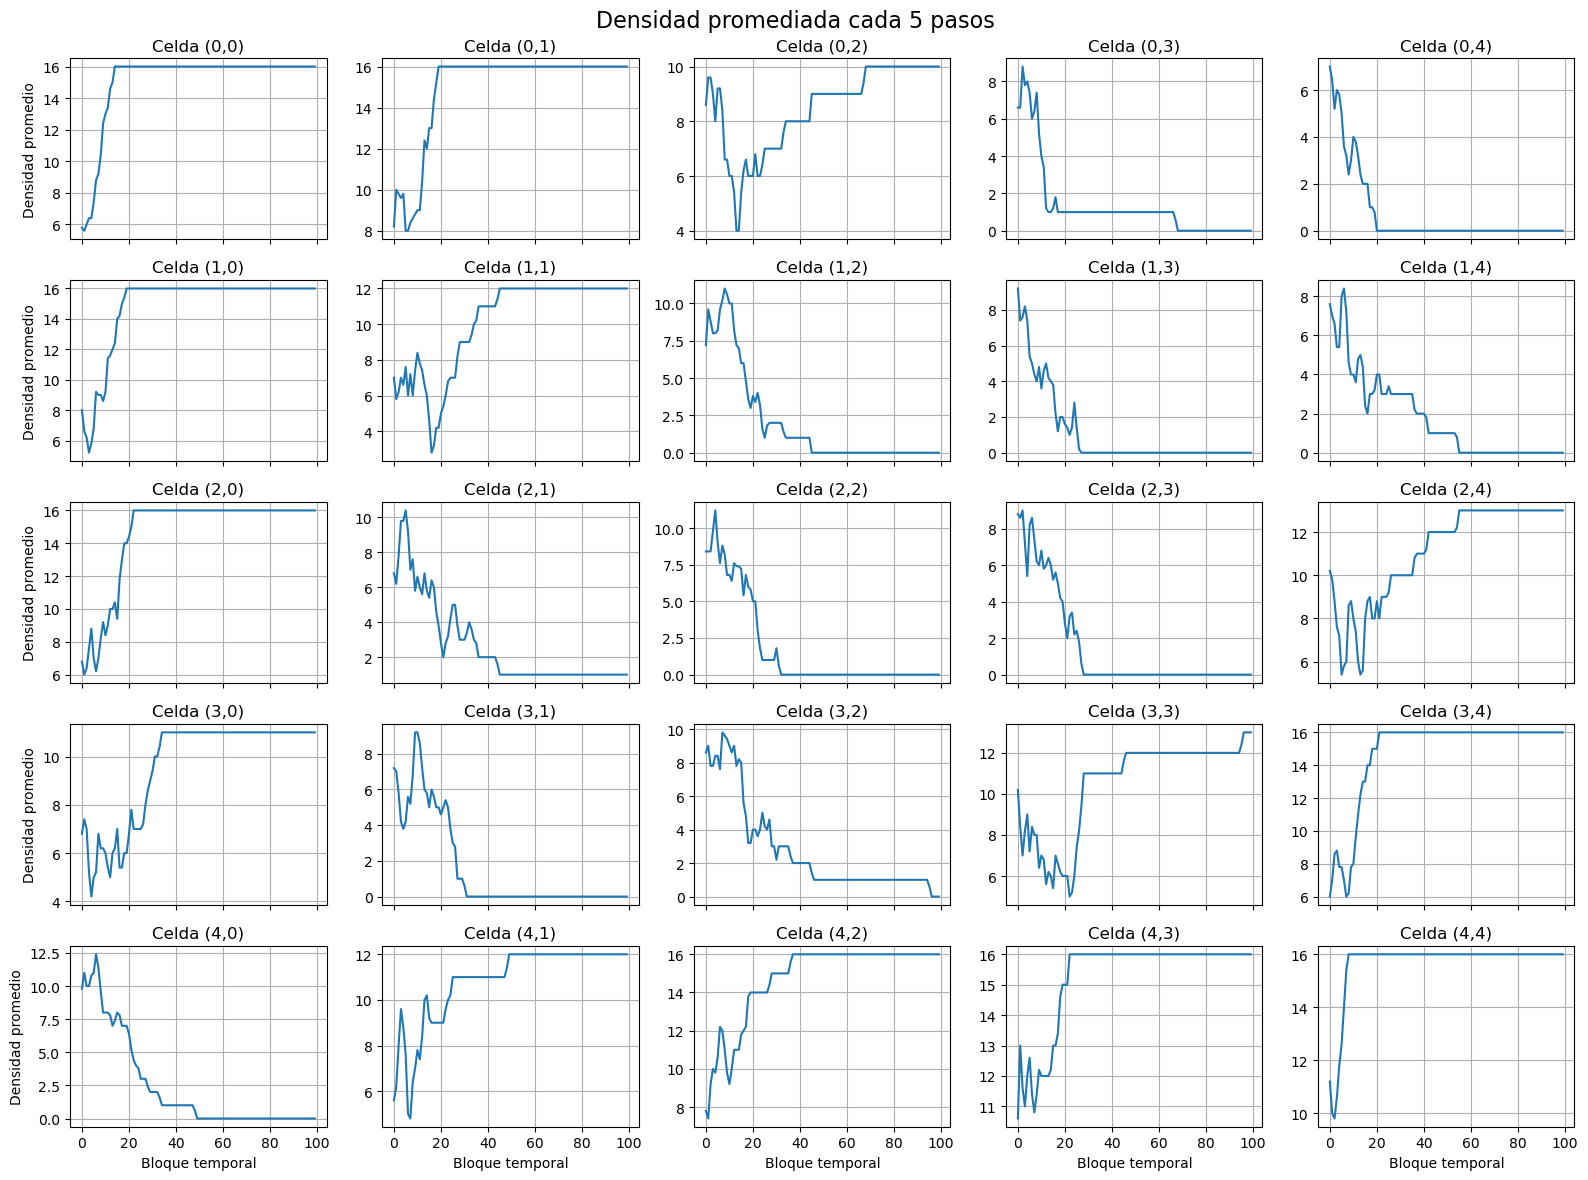

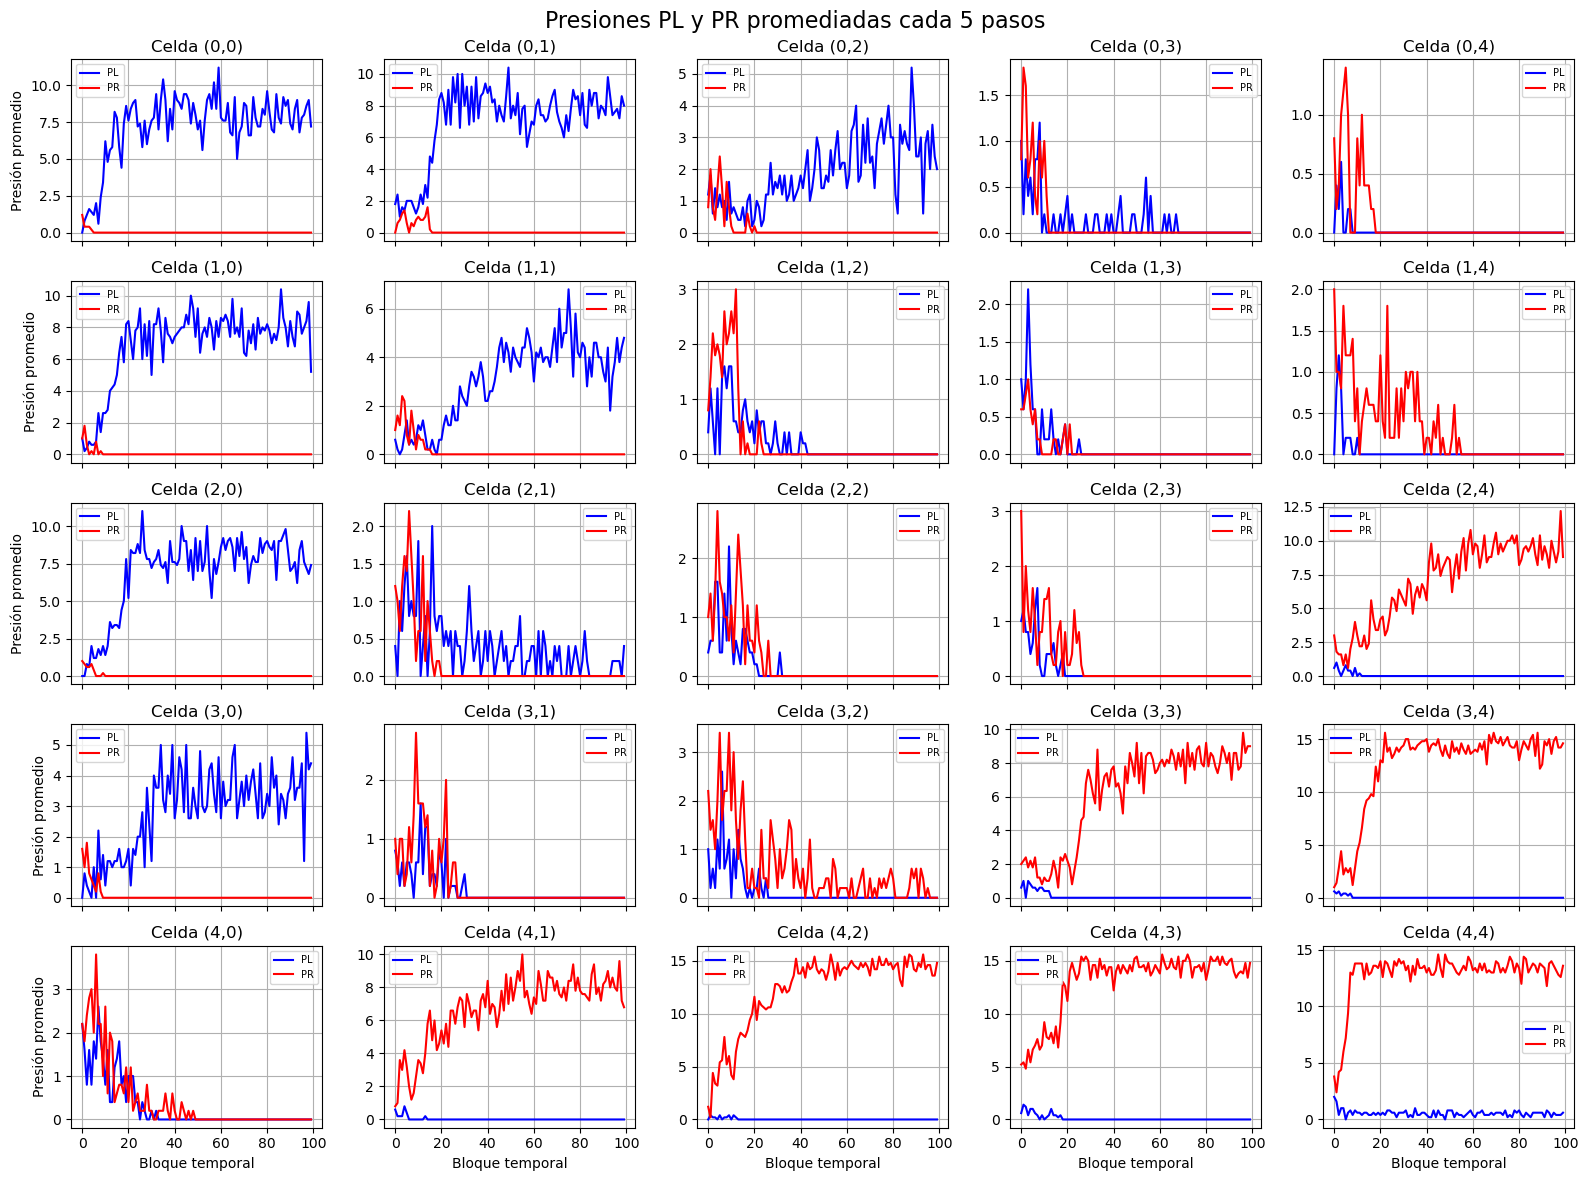

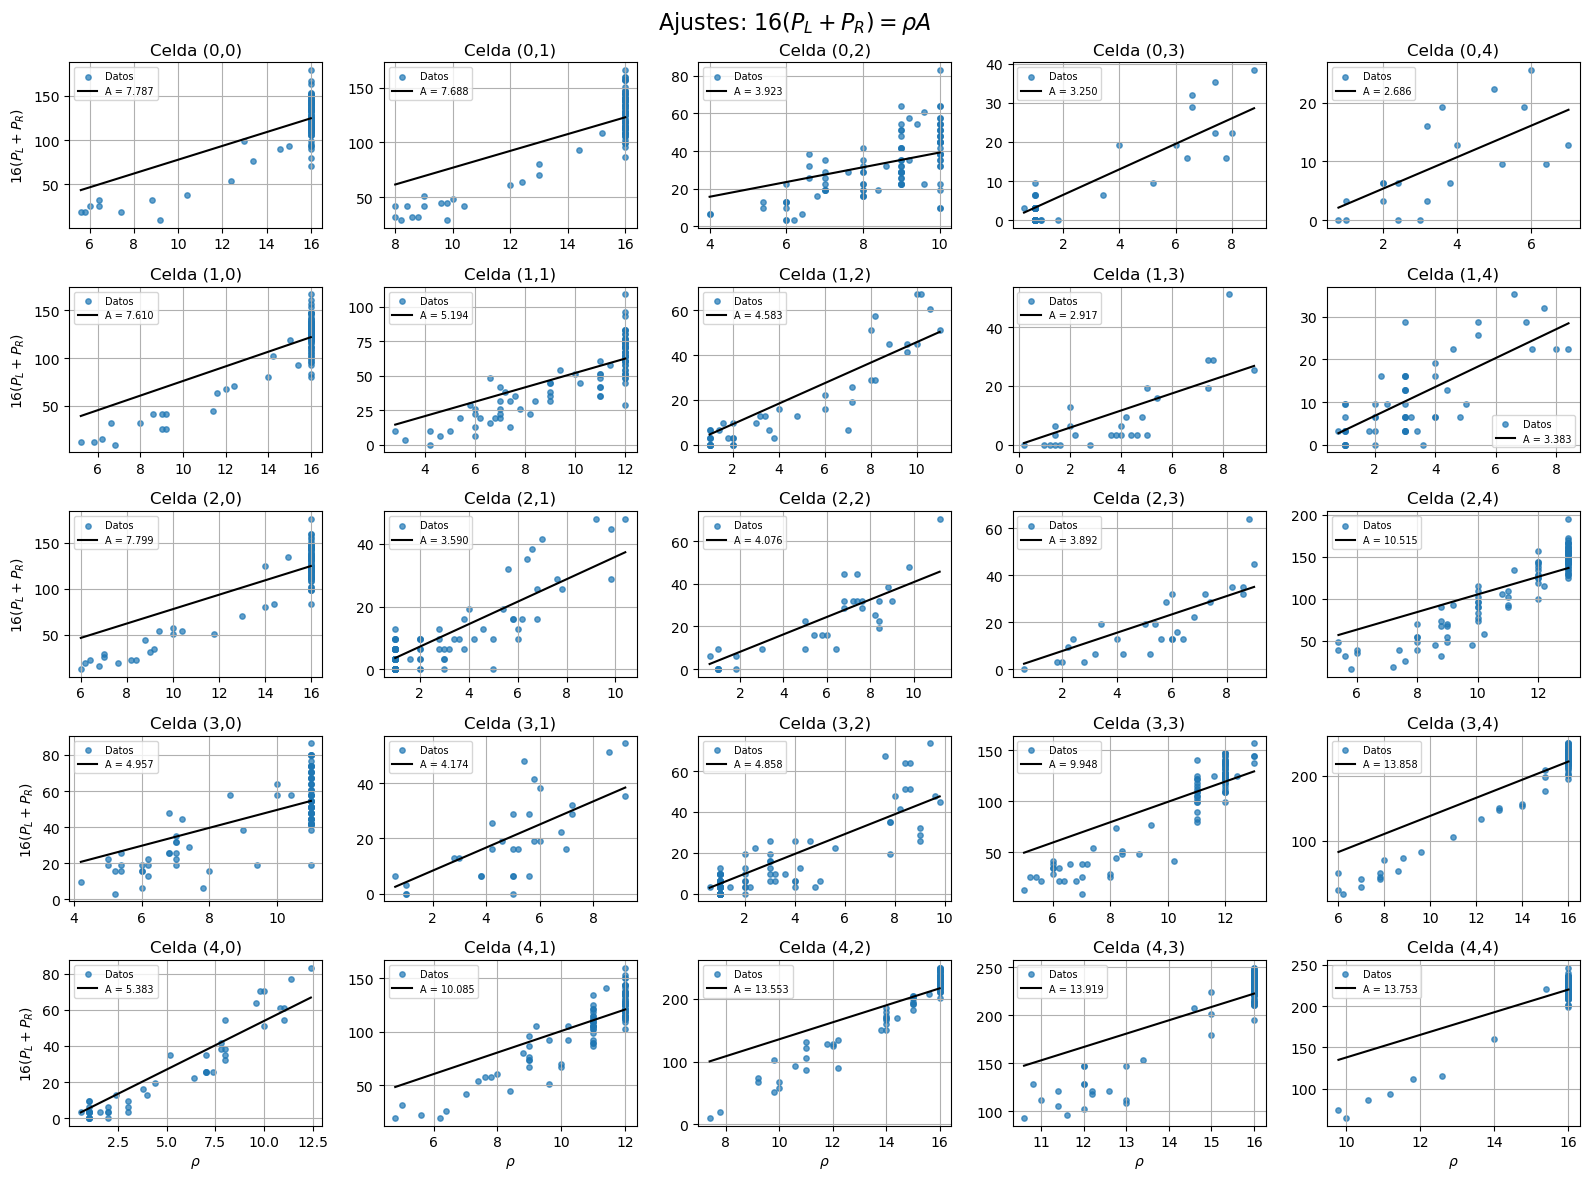


Matriz de valores de A:
[[ 7.78651574  7.68785618  3.92304189  3.25020375  2.68623664]
 [ 7.60970958  5.19404877  4.58302273  2.91663745  3.38332635]
 [ 7.79851681  3.59008408  4.07626512  3.89157957 10.5145512 ]
 [ 4.95677424  4.17394294  4.85848984  9.94842598 13.85750548]
 [ 5.38265816 10.08510001 13.55272008 13.91931346 13.75255573]]

Matriz de valores de A redondeada:
[[ 7.787  7.688  3.923  3.25   2.686]
 [ 7.61   5.194  4.583  2.917  3.383]
 [ 7.799  3.59   4.076  3.892 10.515]
 [ 4.957  4.174  4.858  9.948 13.858]
 [ 5.383 10.085 13.553 13.919 13.753]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# LEER FICHERO
# ============================================================

def leer_matrices_txt(nombre_fichero):
    """
    Lee un txt donde cada bloque separado por líneas vacías
    representa una matriz en un instante temporal.

    Devuelve un array:
        datos[tiempo, fila, columna]
    """

    with open(nombre_fichero, "r", encoding="utf-8") as f:
        texto = f.read().strip()

    bloques = texto.split("\n\n")

    matrices = []

    for bloque in bloques:

        if bloque.strip() == "":
            continue

        lineas = bloque.strip().split("\n")
        matriz = []

        for linea in lineas:
            if linea.strip() != "":
                fila = list(map(float, linea.split()))
                matriz.append(fila)

        matrices.append(matriz)

    datos = np.array(matrices)

    return datos


# ============================================================
# PROMEDIAR CADA 5 PASOS
# ============================================================

def promedio_cada_5_pasos(datos):
    """
    Crea un nuevo array donde cada matriz es la media
    de 5 matrices consecutivas.

    datos_promedio[0] = media de datos[0:5]
    datos_promedio[1] = media de datos[5:10]
    datos_promedio[2] = media de datos[10:15]
    etc.
    """

    num_tiempos = datos.shape[0]
    num_filas = datos.shape[1]
    num_columnas = datos.shape[2]

    num_bloques = num_tiempos // 5

    datos_promedio = []

    for bloque in range(num_bloques):

        inicio = bloque * 5
        final = inicio + 5

        matriz_media = np.zeros((num_filas, num_columnas))

        for t in range(inicio, final):
            matriz_media = matriz_media + datos[t]

        matriz_media = matriz_media / 5

        datos_promedio.append(matriz_media)

    datos_promedio = np.array(datos_promedio)

    return datos_promedio


# ============================================================
# PLOTEAR UNA VARIABLE EN GRID
# ============================================================

def plot_grid(datos, titulo, ylabel):
    """
    Plotea la evolución temporal de cada celda del grid.
    """

    num_tiempos = datos.shape[0]
    num_filas = datos.shape[1]
    num_columnas = datos.shape[2]

    tiempos = np.arange(num_tiempos)

    fig, axs = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(16, 12),
        sharex=True
    )

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            ax.plot(tiempos, datos[:, i, j])

            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel("Bloque temporal")

            if j == 0:
                ax.set_ylabel(ylabel)

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()


# ============================================================
# PLOTEAR PL Y PR JUNTAS EN GRID
# ============================================================

def plot_grid_PL_PR(presionL, presionR):
    """
    Plotea PL y PR juntas para cada celda.
    PL en azul.
    PR en rojo.
    """

    num_tiempos = presionL.shape[0]
    num_filas = presionL.shape[1]
    num_columnas = presionL.shape[2]

    tiempos = np.arange(num_tiempos)

    fig, axs = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(16, 12),
        sharex=True
    )

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            ax.plot(tiempos, presionL[:, i, j], color="blue", label="PL")
            ax.plot(tiempos, presionR[:, i, j], color="red", label="PR")

            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel("Bloque temporal")

            if j == 0:
                ax.set_ylabel("Presión promedio")

            ax.legend(fontsize=7)

    fig.suptitle("Presiones PL y PR promediadas cada 5 pasos", fontsize=16)
    plt.tight_layout()
    plt.show()


# ============================================================
# CALCULAR A Y PLOTEAR AJUSTES
# ============================================================

def calcular_A_y_plot_ajustes(densidad, presionL, presionR):
    """
    Ajusta, para cada celda del grid:

        16 * (PL + PR) = rho * A

    Es decir:

        y = A*x

    donde:
        x = rho = densidad
        y = 16 * (PL + PR)

    El ajuste se hace pasando por el origen.
    """

    num_tiempos = densidad.shape[0]
    num_filas = densidad.shape[1]
    num_columnas = densidad.shape[2]

    matriz_A = np.zeros((num_filas, num_columnas))

    fig, axs = plt.subplots(
        num_filas,
        num_columnas,
        figsize=(16, 12)
    )

    for i in range(num_filas):
        for j in range(num_columnas):

            ax = axs[i, j]

            rho = densidad[:, i, j]
            y = 16 * (presionL[:, i, j] + presionR[:, i, j])

            # Quitamos puntos con rho = 0 para evitar problemas
            rho_ajuste = []
            y_ajuste = []

            for k in range(num_tiempos):
                if rho[k] != 0:
                    rho_ajuste.append(rho[k])
                    y_ajuste.append(y[k])

            rho_ajuste = np.array(rho_ajuste)
            y_ajuste = np.array(y_ajuste)

            # Ajuste y = A*rho pasando por el origen
            if np.sum(rho_ajuste**2) != 0:
                A = np.sum(rho_ajuste * y_ajuste) / np.sum(rho_ajuste**2)
            else:
                A = np.nan

            matriz_A[i, j] = A

            # Plot de los puntos
            ax.scatter(rho_ajuste, y_ajuste, s=15, alpha=0.7, label="Datos")

            # Recta ajustada
            if len(rho_ajuste) > 0:
                rho_recta = np.linspace(np.min(rho_ajuste), np.max(rho_ajuste), 100)
                y_recta = A * rho_recta

                ax.plot(
                    rho_recta,
                    y_recta,
                    color="black",
                    label=f"A = {A:.3f}"
                )

            ax.set_title(f"Celda ({i},{j})")
            ax.grid(True)

            if i == num_filas - 1:
                ax.set_xlabel(r"$\rho$")

            if j == 0:
                ax.set_ylabel(r"$16(P_L + P_R)$")

            ax.legend(fontsize=7)

    fig.suptitle(r"Ajustes: $16(P_L + P_R) = \rho A$", fontsize=16)
    plt.tight_layout()
    plt.show()

    return matriz_A


# ============================================================
# PROGRAMA PRINCIPAL
# ============================================================

densidad = leer_matrices_txt("densidad.txt")
presionL = leer_matrices_txt("presionL.txt")
presionR = leer_matrices_txt("presionR.txt")

print("Dimensiones originales:")
print("densidad:", densidad.shape)
print("presionL:", presionL.shape)
print("presionR:", presionR.shape)


# Comprobación de seguridad
if densidad.shape != presionL.shape or densidad.shape != presionR.shape:
    raise ValueError("Los tres ficheros no tienen las mismas dimensiones.")


# ============================================================
# PROMEDIO CADA 5 PASOS
# ============================================================

densidad_promedio = promedio_cada_5_pasos(densidad)
presionL_promedio = promedio_cada_5_pasos(presionL)
presionR_promedio = promedio_cada_5_pasos(presionR)

print("\nDimensiones promediadas:")
print("densidad_promedio:", densidad_promedio.shape)
print("presionL_promedio:", presionL_promedio.shape)
print("presionR_promedio:", presionR_promedio.shape)


# ============================================================
# PLOTS DE EVOLUCIÓN TEMPORAL PROMEDIADA
# ============================================================

plot_grid(
    densidad_promedio,
    titulo="Densidad promediada cada 5 pasos",
    ylabel="Densidad promedio"
)

plot_grid_PL_PR(
    presionL_promedio,
    presionR_promedio
)


# ============================================================
# AJUSTE 16(PL + PR) = rho * A
# ============================================================

matriz_A = calcular_A_y_plot_ajustes(
    densidad_promedio,
    presionL_promedio,
    presionR_promedio
)

print("\nMatriz de valores de A:")
print(matriz_A)

print("\nMatriz de valores de A redondeada:")
print(np.round(matriz_A, 3))